<a href="https://colab.research.google.com/github/shaimathamer/Mapping_Test/blob/main/Code/Model_Mapping_Test.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# After preparing the data, split it into training, validation, and test sets for model development and evaluation.

In [49]:
import os
import shutil
import random
from google.colab import drive

# Step 1: Mount Google Drive
drive.mount('/content/drive')

# Step 2: Define dataset paths
base_dir = "/content/drive/MyDrive/Mapping_test/"
hospital_dir = os.path.join(base_dir, "hospital_augmented")
non_hospital_dir = os.path.join(base_dir, "undersample_non_hospital")

# Output folders for split dataset
dataset_split = "/content/drive/MyDrive/dataset_split_Uganda_Model"
train_dir = os.path.join(dataset_split, "train")
val_dir = os.path.join(dataset_split, "val")
test_dir = os.path.join(dataset_split, "test")

# Step 3: Check if source folders exist
if not os.path.exists(hospital_dir) or not os.path.exists(non_hospital_dir):
    raise FileNotFoundError("One or both source folders do not exist. Check your Google Drive paths.")

# Step 4: List images
hospital_images = [f for f in os.listdir(hospital_dir) if os.path.isfile(os.path.join(hospital_dir, f))]
non_hospital_images = [f for f in os.listdir(non_hospital_dir) if os.path.isfile(os.path.join(non_hospital_dir, f))]

if not hospital_images or not non_hospital_images:
    raise ValueError("No images found in one or both folders.")

print(f"Found {len(hospital_images)} hospital images.")
print(f"Found {len(non_hospital_images)} non-hospital images.")

# Step 5: Undersample non-hospital images to match hospital images
random.shuffle(non_hospital_images)
non_hospital_images = non_hospital_images[:len(hospital_images)]  # Match hospital count

# Step 6: Create directories for train/val/test splits (Clear old data first!)
def create_clean_directory(path):
    if os.path.exists(path):
        shutil.rmtree(path)  # Delete old contents
    os.makedirs(path, exist_ok=True)

for folder in [train_dir, val_dir, test_dir]:
    create_clean_directory(os.path.join(folder, "hospital_augmented"))
    create_clean_directory(os.path.join(folder, "undersample_non_hospital"))

# Step 7: Function to split and copy images
def split_and_copy(images, src_folder, category):
    random.shuffle(images)

    train_split = int(0.8 * len(images))
    val_split = int(0.9 * len(images))

    for i, img in enumerate(images):
        src = os.path.join(src_folder, img)

        if i < train_split:
            dest_folder = os.path.join(train_dir, category)
        elif i < val_split:
            dest_folder = os.path.join(val_dir, category)
        else:
            dest_folder = os.path.join(test_dir, category)

        shutil.copy(src, os.path.join(dest_folder, img))

# Step 8: Apply function to hospital and non-hospital images
split_and_copy(hospital_images, hospital_dir, "hospital_augmented")
split_and_copy(non_hospital_images, non_hospital_dir, "undersample_non_hospital")

# Step 9: Print the number of images in each split folder
def count_images(folder, category):
    path = os.path.join(folder, category)
    return len([f for f in os.listdir(path) if os.path.isfile(os.path.join(path, f))])

print("\nFinal dataset split counts:")
for split in ["train", "val", "test"]:
    hospital_count = count_images(os.path.join(dataset_split, split), "hospital_augmented")
    non_hospital_count = count_images(os.path.join(dataset_split, split), "undersample_non_hospital")
    print(f"{split.capitalize()} - Hospital: {hospital_count}, Non-Hospital: {non_hospital_count}")

print("\nDataset successfully split into Train (80%), Validation (10%), and Test (10%) sets.")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Found 585 hospital images.
Found 600 non-hospital images.

Final dataset split counts:
Train - Hospital: 468, Non-Hospital: 468
Val - Hospital: 58, Non-Hospital: 58
Test - Hospital: 59, Non-Hospital: 59

Dataset successfully split into Train (80%), Validation (10%), and Test (10%) sets.


# Check the number of images in each folder to ensure proper data distribution.

In [50]:
import os
import pandas as pd

# Define dataset paths
dataset_dir = "/content/drive/MyDrive/dataset_split_Uganda_Model"  # Use full path
categories = ["hospital_augmented", "undersample_non_hospital"]
splits = ["train", "val", "test"]

# Count images in each category and split
data = []

for split in splits:
    for category in categories:
        folder_path = os.path.join(dataset_dir, split, category)

        # Debugging: Print folder path
        print(f"Checking: {folder_path}")

        if os.path.exists(folder_path):
            count = len(os.listdir(folder_path))
        else:
            print(f"Warning: {folder_path} does not exist.")
            count = 0  # If the folder doesn't exist, assume 0 images

        data.append([split, category, count])

# Create DataFrame
df_counts = pd.DataFrame(data, columns=["Dataset Split", "Category", "Number of Images"])

# Display DataFrame
print(df_counts)


Checking: /content/drive/MyDrive/dataset_split_Uganda_Model/train/hospital_augmented
Checking: /content/drive/MyDrive/dataset_split_Uganda_Model/train/undersample_non_hospital
Checking: /content/drive/MyDrive/dataset_split_Uganda_Model/val/hospital_augmented
Checking: /content/drive/MyDrive/dataset_split_Uganda_Model/val/undersample_non_hospital
Checking: /content/drive/MyDrive/dataset_split_Uganda_Model/test/hospital_augmented
Checking: /content/drive/MyDrive/dataset_split_Uganda_Model/test/undersample_non_hospital
  Dataset Split                  Category  Number of Images
0         train        hospital_augmented               468
1         train  undersample_non_hospital               468
2           val        hospital_augmented                58
3           val  undersample_non_hospital                58
4          test        hospital_augmented                59
5          test  undersample_non_hospital                59


Professional Deep Learning Model for Hospital Detection We'll create a CNN (Convolutional Neural Network) to classify hospitals vs. non-hospitals using TensorFlow/Keras. The model will be: ✅ Efficient: Runs on CPU in a few hours. ✅ Accurate: Uses data augmentation and transfer learning (MobileNetV2). ✅ Evaluated: Reports accuracy, precision, recall, F1-score, and confusion matrix.

In [51]:
!pip install tensorflow numpy pandas matplotlib seaborn scikit-learn

Step 2: Load Required Libraries


In [52]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, Flatten, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from sklearn.metrics import classification_report, confusion_matrix

Step 3: Set Dataset Paths

In [53]:
dataset_dir = "content/dataset_split_Uganda_Model"
train_dir = os.path.join(dataset_dir, "train")
val_dir = os.path.join(dataset_dir, "val")
test_dir = os.path.join(dataset_dir, "test")

# Define classes
categories = ["hospital_augmented", "undersample_non_hospital"]

Step 4: Data Preprocessing

In [54]:
import os
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam

# Define paths and parameters
train_dir = "/content/drive/MyDrive/dataset_split_Uganda_Model/train"
val_dir = "/content/drive/MyDrive/dataset_split_Uganda_Model/val"
test_dir = "/content/drive/MyDrive/dataset_split_Uganda_Model/test"
IMG_SIZE = (224, 224)  # Standard input size for MobileNetV2
BATCH_SIZE = 32
EPOCHS = 10  # Set to the desired number of epochs

# Use only rescaling for training, validation, and test datasets
datagen_rescale = ImageDataGenerator(rescale=1./255)

# Load datasets with rescaling
train_generator = datagen_rescale.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary"  # Assuming binary classification: hospital vs non-hospital
)

val_generator = datagen_rescale.flow_from_directory(
    val_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False  # No shuffling for validation set
)

test_generator = datagen_rescale.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False  # No shuffling for test set
)




Found 936 images belonging to 2 classes.
Found 116 images belonging to 2 classes.
Found 118 images belonging to 2 classes.


In [55]:
import os
import pandas as pd

# Define dataset paths
dataset_dir = "/content/drive/MyDrive/dataset_split_Uganda_Model"
categories = ["hospital_augmented", "undersample_non_hospital"]
splits = ["train", "val", "test"]

# Count images in each category and split
data = []

for split in splits:
    for category in categories:
        folder_path = os.path.join(dataset_dir, split, category)

        if os.path.exists(folder_path):
            # Filter only image files
            count = len([f for f in os.listdir(folder_path) if f.endswith(('.png', '.jpg', '.jpeg'))])
        else:
            print(f"Warning: {folder_path} does not exist.")
            count = 0  # If the folder doesn't exist, assume 0 images

        data.append([split, category, count])

# Create DataFrame
df_counts = pd.DataFrame(data, columns=["Dataset Split", "Category", "Number of Images"])

# Display DataFrame
print(df_counts)


  Dataset Split                  Category  Number of Images
0         train        hospital_augmented               468
1         train  undersample_non_hospital               468
2           val        hospital_augmented                58
3           val  undersample_non_hospital                58
4          test        hospital_augmented                59
5          test  undersample_non_hospital                59


Step 5: Build the Deep Learning Model (Using MobileNetV2)

In [56]:
# Load MobileNetV2 without top layers
base_model = MobileNetV2(weights="imagenet", include_top=False, input_shape=(224, 224, 3))

# Freeze base model layers (for transfer learning)
base_model.trainable = False

# Ensure proper layer connection
x = base_model.output
x = GlobalAveragePooling2D()(x)  # Reduce feature maps to a single vector
x = Dense(128, activation="relu")(x)
x = Dropout(0.3)(x)
output_layer = Dense(1, activation="sigmoid")(x)  # Binary classification

# Create model
model = Model(inputs=base_model.input, outputs=output_layer)

# Compile model
model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

# Show model summary
model.summary()


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3             │ (None, 224, 224, 3)    │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ Conv1 (Conv2D)            │ (None, 112, 112, 32)   │            864 │ input_layer_3[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ bn_Conv1                  │ (None, 112, 112, 32)   │            128 │ Conv1[0][0]            │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ Conv1_relu (ReLU)         │ (None, 112, 112, 32)   │              0 │ bn_Conv1[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ expanded_conv_depthwise   │ (None, 112, 112, 32)   │            288 │ Conv1_relu[0][0]       │
│ (DepthwiseConv2D)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ expanded_conv_depthwise_… │ (None, 112, 112, 32)   │            128 │ expanded_conv_depthwi… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ expanded_conv_depthwise_… │ (None, 112, 112, 32)   │              0 │ expanded_conv_depthwi… │
│ (ReLU)                    │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ expanded_conv_project     │ (None, 112, 112, 16)   │            512 │ expanded_conv_depthwi… │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ expanded_conv_project_BN  │ (None, 112, 112, 16)   │             64 │ expanded_conv_project… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block_1_expand (Conv2D)   │ (None, 112, 112, 96)   │          1,536 │ expanded_conv_project… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block_1_expand_BN         │ (None, 112, 112, 96)   │            384 │ block_1_expand[0][0]   │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block_1_expand_relu       │ (None, 112, 112, 96)   │              0 │ block_1_expand_BN[0][… │
│ (ReLU)                    │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block_1_pad               │ (None, 113, 113, 96)   │              0 │ block_1_expand_relu[0… │
│ (ZeroPadding2D)           │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block_1_depthwise         │ (None, 56, 56, 96)     │            864 │ block_1_pad[0][0]      │
│ (DepthwiseConv2D)         │                        │                │                        │
├──────────────────────

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Step 6: Train the Model Now, train the model using the prepared dataset.

Define Training Parameters and Start Training

Remove Corrupted Image

In [57]:
from PIL import Image
import os

def check_images(directory):
    for subdir, dirs, files in os.walk(directory):
        for file in files:
            img_path = os.path.join(subdir, file)
            try:
                with Image.open(img_path) as img:
                    img.verify()  # Verify if the image is valid
            except (IOError, SyntaxError) as e:
                print(f"Corrupted or invalid image: {file}")

check_images(train_dir)
check_images(val_dir)
check_images(test_dir)


In [ ]:
import shutil

def remove_corrupted_images(directory):
    for subdir, dirs, files in os.walk(directory):
        for file in files:
            img_path = os.path.join(subdir, file)
            try:
                with Image.open(img_path) as img:
                    img.verify()  # Verify image
            except (IOError, SyntaxError):
                print(f"Removing corrupted image: {file}")
                os.remove(img_path)  # Or shutil.move(img_path, "path/to/backup") if you want to keep them

# Run the removal function on all dataset directories
remove_corrupted_images(train_dir)
remove_corrupted_images(val_dir)
remove_corrupted_images(test_dir)


In [ ]:
import os

# Check if the file exists in the specified directory
file_path = '/content/drive/MyDrive/dataset_split_Uganda_Model/train/undersample_non_hospital/non_hospital_86.png'
if not os.path.exists(file_path):
    print(f"File not found: {file_path}")
else:
    print(f"File exists: {file_path}")


In [ ]:
import os

def remove_missing_image_from_directory(directory, file_name):
    file_path = os.path.join(directory, file_name)
    if os.path.exists(file_path):
        os.remove(file_path)
        print(f"Removed missing image: {file_name}")
    else:
        print(f"Image {file_name} does not exist.")

# Define the path of your directory and the image name to remove
directory = '/content/drive/MyDrive/dataset_split_Uganda_Model/train/undersample_non_hospital/'
remove_missing_image_from_directory(directory, 'non_hospital_86.png')


In [58]:
EPOCHS = 10  # You can increase this if needed
BATCH_SIZE = 32

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS
)


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 67s 2s/step - accuracy: 0.8025 - loss: 0.4805 - val_accuracy: 0.9569 - val_loss: 0.0987
Epoch 2/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 61s 2s/step - accuracy: 0.9656 - loss: 0.0900 - val_accuracy: 0.9828 - val_loss: 0.0461
Epoch 3/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 61s 2s/step - accuracy: 0.9898 - loss: 0.0285 - val_accuracy: 0.9914 - val_loss: 0.0262
Epoch 4/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 57s 2s/step - accuracy: 0.9932 - loss: 0.0266 - val_accuracy: 0.9914 - val_loss: 0.0255
Epoch 5/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 59s 2s/step - accuracy: 0.9960 - loss: 0.0148 - val_accuracy: 0.9914 - val_loss: 0.0199
Epoch 6/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 61s 2s/step - accuracy: 1.0000 - loss: 0.0084 - val_accuracy: 1.0000 - val_loss: 0.0136
Epoch 7/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 58s 2s/step - accuracy: 0.9959 - loss: 0.0111 - val_accuracy: 0.9914 - val_loss: 0.0129
Epoch 8/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 59s 2s/step - accuracy: 0.9980 - loss: 0.0085 - val_accuracy: 0.9914 - val_loss:

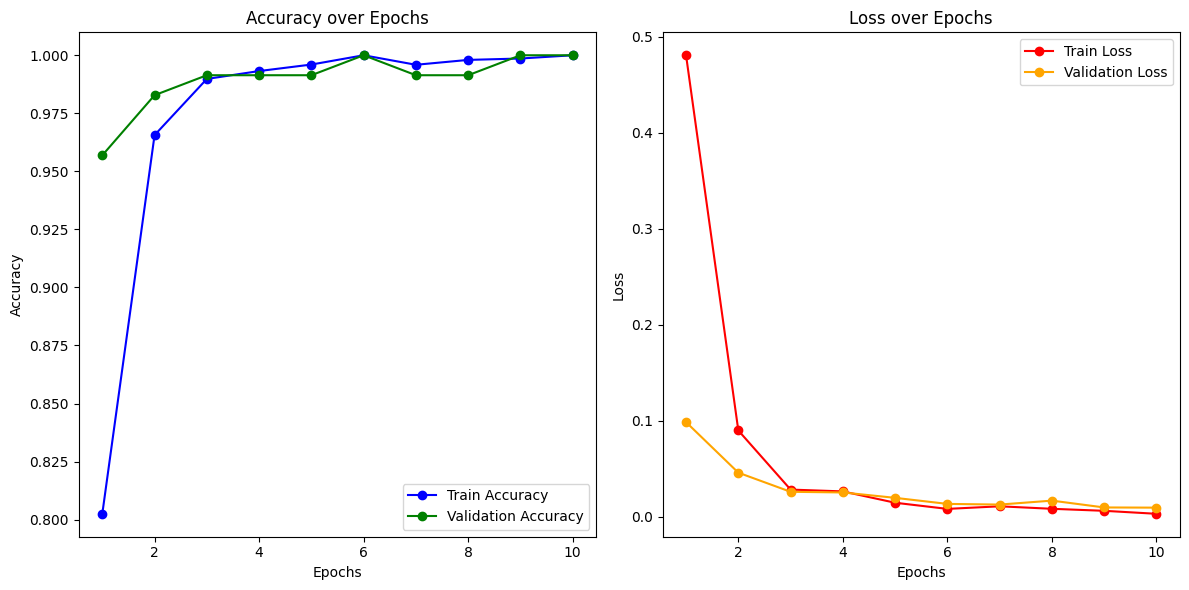

In [61]:
import matplotlib.pyplot as plt

# Example training history values from your training log
epochs = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

# Replace these lists with the actual values from your training process
train_accuracy = [0.8025, 0.9656, 0.9898, 0.9932, 0.9960, 1.0000, 0.9959, 0.9980, 0.9986, 1.0000]
val_accuracy = [0.9569, 0.9828, 0.9914, 0.9914, 0.9914, 1.0000, 0.9914, 0.9914, 1.0000, 1.0000]

train_loss = [0.4805, 0.0900, 0.0285, 0.0266, 0.0148, 0.0084, 0.0111, 0.0085, 0.0064, 0.0033]
val_loss = [0.0987, 0.0461, 0.0262, 0.0255, 0.0199, 0.0136, 0.0129, 0.0170, 0.0099, 0.0097]

# Plot accuracy
plt.figure(figsize=(12, 6))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(epochs, train_accuracy, label='Train Accuracy', color='blue', marker='o')
plt.plot(epochs, val_accuracy, label='Validation Accuracy', color='green', marker='o')
plt.title('Accuracy over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(epochs, train_loss, label='Train Loss', color='red', marker='o')
plt.plot(epochs, val_loss, label='Validation Loss', color='orange', marker='o')
plt.title('Loss over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Show the plots
plt.tight_layout()
plt.show()


4/4 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step
                          precision    recall  f1-score   support

      hospital_augmented       0.98      1.00      0.99        59
undersample_non_hospital       1.00      0.98      0.99        59

                accuracy                           0.99       118
               macro avg       0.99      0.99      0.99       118
            weighted avg       0.99      0.99      0.99       118



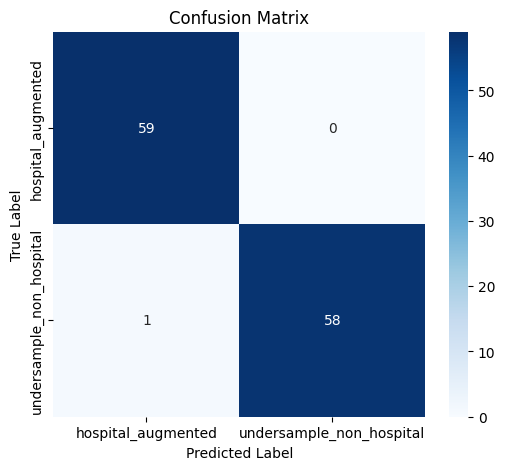

In [59]:
# Get predictions
y_pred = model.predict(test_generator)
y_pred_classes = (y_pred > 0.5).astype(int).flatten()  # Convert probabilities to 0 or 1

# Get true labels
y_true = test_generator.classes

# Print classification report
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

print(classification_report(y_true, y_pred_classes, target_names=categories))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=categories, yticklabels=categories)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()
